In [1]:
import numpy as np
import modules.tools as tools
from numpy import cos, sin, pi, exp, sqrt, sinh
import scipy.integrate as integrate
from numpy.linalg import norm

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from functools import partial
import scipy.optimize as optimization

In [3]:
s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

In [4]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

## Read data of DFT bands

### Standard BZ path

In [5]:
# data that contains the exact DFT bands
data_DFT = []

f = open('DFT_data/wannier90_band.dat','r')
lines = f.readlines()
data_DFT = []
for x in lines:
    data_DFT.append(x)
f.close()

In [6]:
# separate the lines into columns
# there are two data sets separated by an empty line

# data set 1
ks_DFT_1 = []
Es_DFT_1 = []

# data set 2
ks_DFT_2 = []
Es_DFT_2 = []

empty_line = 0
for line in data_DFT:
    columns = line.split() # split line string into separate words
    
    if len(columns)==0:
        empty_line += 1
        continue
        
    if empty_line == 0:
        ks_DFT_1.append(float(columns[0]))
        Es_DFT_1.append(float(columns[1]))
    elif empty_line == 1:
        ks_DFT_2.append(float(columns[0]))
        Es_DFT_2.append(float(columns[1]))
    else:
        break

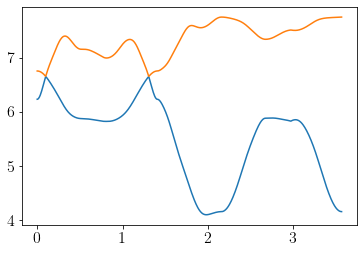

In [7]:
plt.plot(ks_DFT_1, Es_DFT_1)
plt.plot(ks_DFT_2, Es_DFT_2)

### BZ path through nodal points

In [8]:
# data that contains the exact DFT bands
data_DFT = []

f = open('DFT_data/wannier90_band_more.dat','r')
lines = f.readlines()
data_DFT = []
for x in lines:
    data_DFT.append(x)
f.close()

In [9]:
# separate the lines into columns
# there are two data sets separated by an empty line

# data set 3
ks_DFT_3 = []
Es_DFT_3 = []

# data set 4
ks_DFT_4 = []
Es_DFT_4 = []

empty_line = 0
for line in data_DFT:
    columns = line.split() # split line string into separate words
    
    if len(columns)==0:
        empty_line += 1
        continue
        
    if empty_line == 0:
        ks_DFT_3.append(float(columns[0]))
        Es_DFT_3.append(float(columns[1]))
    elif empty_line == 1:
        ks_DFT_4.append(float(columns[0]))
        Es_DFT_4.append(float(columns[1]))
    else:
        break

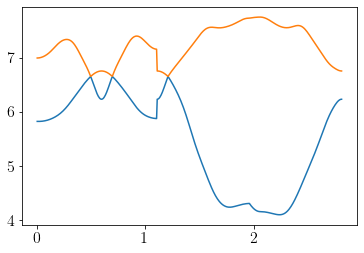

In [10]:
plt.plot(ks_DFT_3, Es_DFT_3)
plt.plot(ks_DFT_4, Es_DFT_4)

## Extract bands close to Gamma

For the low-energy toy-model fit, only the paths Gamma-K, Gamma-M,  and Gamma-A are relevant. Therefore, we separate the these paths from the data:

In [11]:
# reciprocal lattice vectors (hexagonal system)
b1 = np.array([0.891864, 0.514918, 0])
b2 = np.array([0, 1.029836, 0])
b3 = np.array([0, 0, 1.505315])
k_basis = np.array([b1,b2,b3])

### Standard BZ path

In [12]:
# define high-symmetry points for the band plot
Gamma = np.array([0,0,0]) @ k_basis
A = np.array([0,0,1/2]) @ k_basis
K = np.array([1/3,1/3,0]) @ k_basis
H = np.array([1/3,1/3,1/2]) @ k_basis
M = np.array([0,1/2,0]) @ k_basis
L = np.array([0,1/2,1/2]) @ k_basis

k_points = [Gamma, M, K, Gamma, A, L, H, A]

In [13]:
# path lengths
l_GM = norm(M-Gamma)
l_MK = norm(K-M)
l_KG = norm(Gamma-K)
l_GA = norm(A-Gamma)

In [14]:
print(l_GM)
print(l_GM + l_MK)
print(l_GM + l_MK + l_KG)
print(l_GM + l_MK + l_KG + l_GA)

0.514918
0.812206
1.4067820688658768
2.159439568865877


In [15]:
# determine nodal-point energy
n = np.argmin(abs((np.array(Es_DFT_1)-np.array(Es_DFT_2))[0:101]))
mu = (Es_DFT_2[n] + Es_DFT_1[n])/2
print(mu)

6.648096000000001


In [16]:
# determine the list ranges for the BZ paths
print(ks_DFT_1[0:101])

[0.0, 0.005149182, 0.010298364, 0.015447546, 0.020596728, 0.02574591, 0.030895092, 0.036044274, 0.041193456, 0.046342638, 0.05149182, 0.056641002, 0.061790184, 0.066939366, 0.072088548, 0.07723773, 0.082386912, 0.087536094, 0.092685276, 0.097834458, 0.10298364, 0.10813282, 0.113282, 0.11843119, 0.12358037, 0.12872955, 0.13387873, 0.13902791, 0.1441771, 0.14932628, 0.15447546, 0.15962464, 0.16477382, 0.16992301, 0.17507219, 0.18022137, 0.18537055, 0.19051973, 0.19566892, 0.2008181, 0.20596728, 0.21111646, 0.21626564, 0.22141483, 0.22656401, 0.23171319, 0.23686237, 0.24201155, 0.24716074, 0.25230992, 0.2574591, 0.26260828, 0.26775746, 0.27290665, 0.27805583, 0.28320501, 0.28835419, 0.29350337, 0.29865256, 0.30380174, 0.30895092, 0.3141001, 0.31924928, 0.32439847, 0.32954765, 0.33469683, 0.33984601, 0.34499519, 0.35014438, 0.35529356, 0.36044274, 0.36559192, 0.3707411, 0.37589029, 0.38103947, 0.38618865, 0.39133783, 0.39648701, 0.4016362, 0.40678538, 0.41193456, 0.41708374, 0.42223292, 0.

In [17]:
ks_GM = np.array(ks_DFT_1[0:101])
Es_GM = np.array([Es_DFT_1[0:101], Es_DFT_2[0:101]]) - mu

ks_GK = ks_DFT_1[273] - np.array(ks_DFT_1[273:157:-1])
Es_GK = np.array([Es_DFT_1[273:157:-1], Es_DFT_2[273:157:-1]]) - mu

ks_GA = np.array(ks_DFT_1[273:420]) - ks_DFT_1[273] # shift to k=0
Es_GA = np.array([Es_DFT_1[273:420], Es_DFT_2[273:420]]) - mu

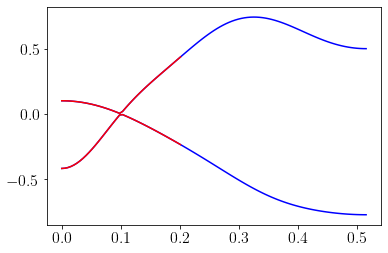

In [18]:
GM_range = range(0,40)

plt.plot(ks_GM, Es_GM[0,:], c='b')
plt.plot(ks_GM, Es_GM[1,:], c='b')
plt.plot(ks_GM[GM_range], Es_GM[0,GM_range], c='r')
plt.plot(ks_GM[GM_range], Es_GM[1,GM_range], c='r')

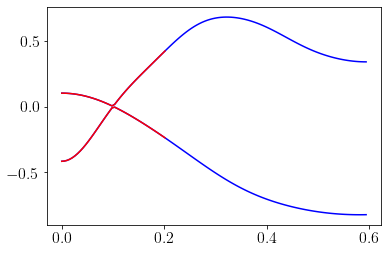

In [19]:
GK_range = range(0,40)

plt.plot(ks_GK, Es_GK[0,:], c='b')
plt.plot(ks_GK, Es_GK[1,:], c='b')
plt.plot(ks_GK[GK_range], Es_GK[0,GK_range], c='r')
plt.plot(ks_GK[GK_range], Es_GK[1,GK_range], c='r')

The nodal loop is indeed circular and the dispersion close to Gamma is almost isotropic. Hence, a fit to a cubic low-energy model is reasonable.

### Addtional path through nodal point along kz

In [20]:
# define high-symmetry points for the band plot
K = np.array([1/3,1/3,0]) @ k_basis
Gamma = np.array([0,0,0]) @ k_basis
M = np.array([0,1/2,0]) @ k_basis
M1 = np.array([0,0.096666,0]) @ k_basis
A1 = np.array([0,0.096666,1/2]) @ k_basis
A = np.array([0,0,1/2]) @ k_basis

k_points = [K, Gamma, M, Gamma, M1, A1, A, Gamma]

In [21]:
# path lengths
l_KG = norm(Gamma-K)
l_GM = norm(M-Gamma)
l_GM1 = norm(M1-Gamma)
l_M1A1 = norm(A1-M1)
l_A1A = norm(A-A1)
l_AG = norm(Gamma-A)

In [22]:
print(l_KG)
print(l_KG + l_GM)
print(l_KG + l_GM + l_GM1, ', start')
print(l_KG + l_GM + l_GM1 + l_M1A1, ', end')
print(l_KG + l_GM + l_GM1 + l_M1A1 + l_A1A)
print(l_KG + l_GM + l_GM1 + l_M1A1 + l_A1A + l_AG)

0.5945760688658769
1.1094940688658768
1.2090441956418767 , start
1.9617016956418767 , end
2.061251822417877
2.813909322417877


In [23]:
# determine the list ranges for the BZ paths
print(ks_DFT_3[204:332])

[1.2090195, 1.2149459, 1.2208723, 1.2267988, 1.2327252, 1.2386517, 1.2445781, 1.2505045, 1.256431, 1.2623574, 1.2682838, 1.2742103, 1.2801367, 1.2860632, 1.2919896, 1.297916, 1.3038425, 1.3097689, 1.3156953, 1.3216218, 1.3275482, 1.3334747, 1.3394011, 1.3453275, 1.351254, 1.3571804, 1.3631068, 1.3690333, 1.3749597, 1.3808862, 1.3868126, 1.392739, 1.3986655, 1.4045919, 1.4105183, 1.4164448, 1.4223712, 1.4282977, 1.4342241, 1.4401505, 1.446077, 1.4520034, 1.4579298, 1.4638563, 1.4697827, 1.4757092, 1.4816356, 1.487562, 1.4934885, 1.4994149, 1.5053413, 1.5112678, 1.5171942, 1.5231207, 1.5290471, 1.5349735, 1.5409, 1.5468264, 1.5527528, 1.5586793, 1.5646057, 1.5705322, 1.5764586, 1.582385, 1.5883115, 1.5942379, 1.6001643, 1.6060908, 1.6120172, 1.6179437, 1.6238701, 1.6297965, 1.635723, 1.6416494, 1.6475758, 1.6535023, 1.6594287, 1.6653552, 1.6712816, 1.677208, 1.6831345, 1.6890609, 1.6949873, 1.7009138, 1.7068402, 1.7127667, 1.7186931, 1.7246195, 1.730546, 1.7364724, 1.7423988, 1.7483253, 

In [24]:
ks_M1A1 = np.array(ks_DFT_3[204:332]) - ks_DFT_3[204]
Es_M1A1 = np.array([Es_DFT_3[204:332], Es_DFT_4[204:332]]) - mu

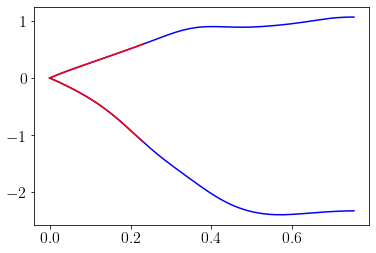

In [25]:
M1A1_range = range(0,40)

plt.plot(ks_M1A1, Es_M1A1[0,:], c='b')
plt.plot(ks_M1A1, Es_M1A1[1,:], c='b')
plt.plot(ks_M1A1[M1A1_range], Es_M1A1[0,M1A1_range], c='r')
plt.plot(ks_M1A1[M1A1_range], Es_M1A1[1,M1A1_range], c='r')

## Fitting

In [26]:
def Ham(kx, ky, kz, a, mu, t, t0, t1, t2):
    ''' returns the tight-binding Hamiltonian of the unstrained system
        at momentum (kx,ky,kz).
        
    '''
    return ((6.*t - t1 - 2.*t*cos(a*kx) - 2.*t*cos(a*ky) - 2.*t*cos(a*kz))*sz + 2.*t2*sin(a*kz)*sx
           + t0*(cos(a*kx)+cos(a*ky))*s0 - mu*s0)

In [27]:
mu = -1.8
t = 1.0
t0 = -1.0
t1 = 0.5
t2 = 1.0
a = 7.045

params = dict(mu=mu, t=t, t0=t0, t1=t1, t2=t2, a=a)

In [28]:
Gamma = [0,0,0]
X = [pi/a, 0, 0]
M = [pi/a, pi/a, 0]
Z = [0, 0, pi/a]

k_points = [M, Gamma, X, Gamma, Z]
k_labels = ['$M$', '$\Gamma$', '$X$', '$\Gamma$', '$Z$']

In [29]:
kline, energies, evecs = tools.compute_bands_3D(Ham, params, k_points)

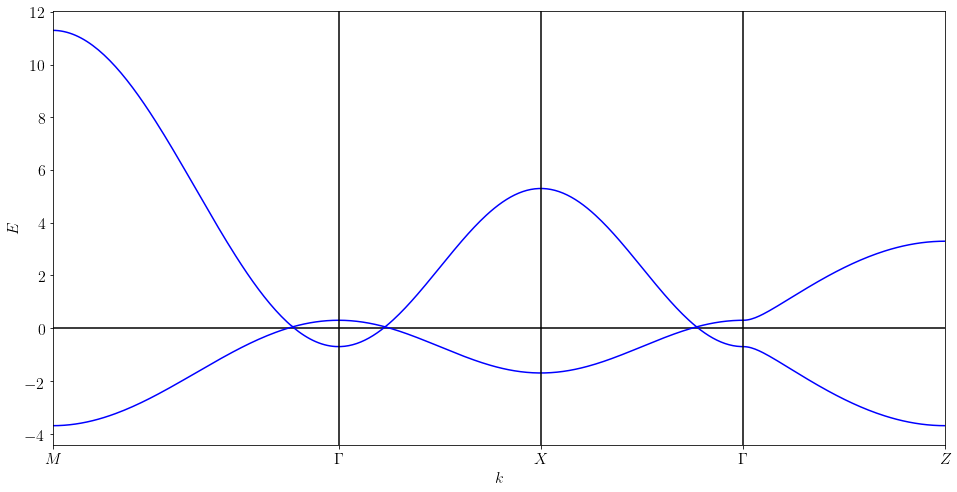

In [30]:
tools.plot_bands_3D(kline, energies, k_labels)

In [31]:
kline[np.argmin(abs(energies[:,0]-energies[:,1]))] - norm(np.array(Gamma)-np.array(M))

0.10256441594402443

In [32]:
def cost_function(Ham, pars):
    # a, mu, t, t0, t1, t2
    
    #a = 7.045

    # valence band Gamma-M (along Gamma-Y in the cubic BZ)
    k1 = ks_GM[GM_range]
    E1 = np.zeros(len(k1))
    for i,k in enumerate(k1):
        E1[i] = np.linalg.eigvalsh(Ham(0.0, k, 0.0, *pars))[0]
    E1 = E1 - Es_GM[0,GM_range]
    
    # conduction band Gamma-M (along Gamma-Y in the cubic BZ)
    k2 = ks_GM[GM_range]
    E2 = np.zeros(len(k2))
    for i,k in enumerate(k2):
        E2[i] = np.linalg.eigvalsh(Ham(0.0,k,0.0, *pars))[1]
    E2 = E2 - Es_GM[1,GM_range]
    
    w12 = np.sqrt(abs(Es_GM[1,GM_range] - Es_GM[0,GM_range]))
    
    alpha_MK = pi/6
    # valence band Gamma-K 
    # (along the same direction with respect to Gamma-X in the cubic BZ)
    k3 = ks_GK[GK_range]
    E3 = np.zeros(len(k3))
    for i,k in enumerate(k3):
        E3[i] = np.linalg.eigvalsh(Ham(k*sin(alpha_MK),k*cos(alpha_MK),0.0, *pars))[0]
    E3 = E3 - Es_GK[0,GK_range]
    
    # conduction band Gamma-K
    # (along the same direction with respect to Gamma-X in the cubic BZ)
    k4 = ks_GK[GK_range]
    E4 = np.zeros(len(k4))
    for i,k in enumerate(k4):
        E4[i] = np.linalg.eigvalsh(Ham(k*sin(alpha_MK),k*cos(alpha_MK),0.0, *pars))[1]
    E4 = E4 - Es_GK[1,GK_range]
    
    w34 = np.sqrt(abs(Es_GK[1,GK_range] - Es_GK[0,GK_range]))
    
    # valence band M1-A1 (along Gamma-Z in the cubic BZ)
    k5 = ks_M1A1[M1A1_range]
    E5 = np.zeros(len(k5))
    for i,k in enumerate(k5):
        E5[i] = np.linalg.eigvalsh(Ham(0.0,M1[1],k, *pars))[0]
    E5 = E5 - Es_M1A1[0,M1A1_range]
    
    # conduction band M1-A1 (along Gamma-Z in the cubic BZ)
    k6 = ks_M1A1[M1A1_range]
    E6 = np.zeros(len(k6))
    for i,k in enumerate(k6):
        E6[i] = np.linalg.eigvalsh(Ham(0.0,M1[1],k, *pars))[1]
    E6 = E6 - Es_M1A1[1,M1A1_range]
    
    w56 = np.sqrt(abs(Es_M1A1[1,M1A1_range] - Es_M1A1[0,M1A1_range]))
    
    # minimize E^2
    # (weighted non-linear least square)
    
    E = np.concatenate((E1/w12, E2/w12, E3/w34, E4/w34, E5/w56, E6/w56))
    
    return np.dot(E, E)

In [33]:
def compare_fit_to_data(Ham, pars):
    # a, mu, t, t0, t1, t2
    
    #a = 7.045

    # valence band Gamma-M (along Gamma-Y in the cubic BZ)
    k1 = ks_GM[GM_range]
    E1 = np.zeros(len(k1))
    for i,k in enumerate(k1):
        E1[i] = np.linalg.eigvalsh(Ham(0.0,k,0.0, *pars))[0]
    E1_data = Es_GM[0,GM_range]
    
    # conduction band Gamma-M (along Gamma-Y in the cubic BZ)
    k2 = ks_GM[GM_range]
    E2 = np.zeros(len(k2))
    for i,k in enumerate(k2):
        E2[i] = np.linalg.eigvalsh(Ham(0.0,k,0.0, *pars))[1]
    E2_data = Es_GM[1,GM_range]
    
    alpha_MK = pi/6
    # valence band Gamma-K 
    # (along the same direction with respect to Gamma-X in the cubic BZ)
    k3 = ks_GK[GK_range]
    E3 = np.zeros(len(k3))
    for i,k in enumerate(k3):
        E3[i] = np.linalg.eigvalsh(Ham(k*sin(alpha_MK),k*cos(alpha_MK),0.0, *pars))[0]
    E3_data = Es_GK[0,GK_range]
    
    # conduction band Gamma-K
    # (along the same direction with respect to Gamma-X in the cubic BZ)
    k4 = ks_GK[GK_range]
    E4 = np.zeros(len(k4))
    for i,k in enumerate(k4):
        E4[i] = np.linalg.eigvalsh(Ham(k*sin(alpha_MK),k*cos(alpha_MK),0.0, *pars))[1]
    E4_data = Es_GK[1,GK_range]
    
    # valence band M1-A1 (along Gamma-Z in the cubic BZ)
    k5 = ks_M1A1[M1A1_range]
    E5 = np.zeros(len(k5))
    for i,k in enumerate(k5):
        E5[i] = np.linalg.eigvalsh(Ham(0.0,M1[1],k, *pars))[0]
    E5_data = Es_M1A1[0,M1A1_range]
    
    # conduction band M1-A1 (along Gamma-Z in the cubic BZ)
    k6 = ks_M1A1[M1A1_range]
    E6 = np.zeros(len(k6))
    for i,k in enumerate(k6):
        E6[i] = np.linalg.eigvalsh(Ham(0.0,M1[1],k, *pars))[1]
    E6_data = Es_M1A1[1,M1A1_range]
    
    plt.figure(figsize=(9,3))
    
    plt.subplot(131)
    plt.title('Along $\Gamma$Y')
    plt.plot(k1, E1_data, c='r')
    plt.plot(k2, E2_data, c='r')
    plt.plot(k1, E1, c='b')
    plt.plot(k2, E2, c='b')
    plt.xlabel('$k$')
    plt.ylabel('$E$')
    
    plt.subplot(132)
    plt.title('Along $\Gamma$K')
    plt.plot(k3, E3_data, c='r')
    plt.plot(k4, E4_data, c='r')
    plt.plot(k3, E3, c='b')
    plt.plot(k4, E4, c='b')
    plt.xlabel('$k$')
    plt.ylabel('$E$')
    
    plt.subplot(133)
    plt.title('Along $Y_1Z_1$')
    plt.plot(k5, E5_data, c='r')
    plt.plot(k6, E6_data, c='r')
    plt.plot(k5, E5, c='b')
    plt.plot(k6, E6, c='b')
    plt.xlabel('$k$')
    plt.ylabel('$E$')

In [34]:
# a, mu, t, t0, t1, t2

bounds = np.array([[5.045,-10.0, 0., -2.0, 0.0, 0.0],
                   [15.045, 10.0, 2., 0.0, 1.0, 2.0]])

guess = np.array([7.045, -1.8, 1.0, -1.0, 0.5, 1.0])

In [35]:
fit_function = partial(cost_function, Ham)
out = optimization.minimize(fit_function, guess, bounds=bounds.T)
params = out['x']
print(params)
print(out)
print

[ 9.68627342 -0.26144741  0.20562036 -0.16470814  0.17698883  0.16911438]
      fun: 2.855522527535915
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>
      jac: array([ 1.12634346e-03, -5.63260549e-02,  9.66338121e-03,  9.04158526e-02,
       -1.53555835e-02,  4.20996571e-05])
  message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
     nfev: 1015
      nit: 106
   status: 0
  success: True
        x: array([ 9.68627342, -0.26144741,  0.20562036, -0.16470814,  0.17698883,
        0.16911438])


<function print>

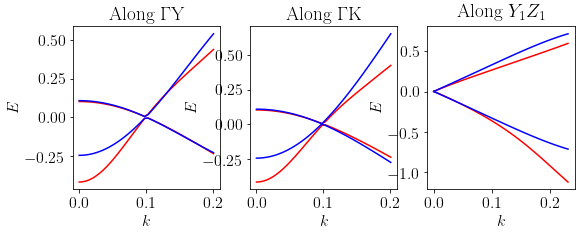

In [36]:
compare_fit_to_data(Ham, params)

Check stability of the solutions with respect to perturbations

In [116]:
# a, mu, t, t0, t1, t2

pert = 0.1 # perturbation strength

bounds = np.array([[5.045,-10.0, 0., -2.0, 0.0, 0.0],
                   [15.045, 10.0, 2., 0.0, 1.0, 2.0]])

guess0 = np.array([9.69, -0.26, 0.21, -0.16, 0.18, 0.17])

In [117]:
n = 50
params_arr = np.zeros((50,6))
fit_function = partial(cost_function, Ham)

for i in range(n):
    print('\r{} of {}'.format(i+1, n), end='')
    guess = (2*pert*np.random.rand(6) - pert) * guess0 + guess0
    out = optimization.minimize(fit_function, guess, bounds=bounds.T)
    params_arr[i,:] = out['x']    

50 of 50

In [118]:
params_av = np.sum(params_arr,0)/n
stdev = np.sqrt(np.sum(params_arr**2,0)/n - params_av**2)
print('parameter averages: ', params_av)
print('standard deviation: ', stdev)
print('relative uncertainty: ', abs(stdev/params_av))

parameter averages:  [ 9.70389059 -0.26108944  0.20545184 -0.16455835  0.17718035  0.16892078]
standard deviation:  [0.26567608 0.01431634 0.00784761 0.00682276 0.00225359 0.0037436 ]
relative uncertainty:  [0.02737831 0.05483307 0.03819682 0.04146101 0.01271919 0.02216189]


The fit solution is stable against small perturbations (at least up to 10 percent).

Plot the solution:

In [121]:
params_keys = ['a', 'mu', 't', 't0', 't1', 't2']
parameters = dict(zip(params_keys, np.array([9.69, -0.26, 0.21, -0.16, 0.18, 0.17])))
a = 9.69

Gamma = [0,0,0]
X = [pi/a, 0, 0]
M = [pi/a, pi/a, 0]
Z = [0, 0, pi/a]

k_points = [Gamma, X, M, Gamma, Z]
k_labels = ['$\Gamma$', '$X$', '$M$', '$\Gamma$', '$Z$']

In [123]:
kline0, energies0, evecs0 = tools.compute_bands_3D(Ham, parameters, k_points)

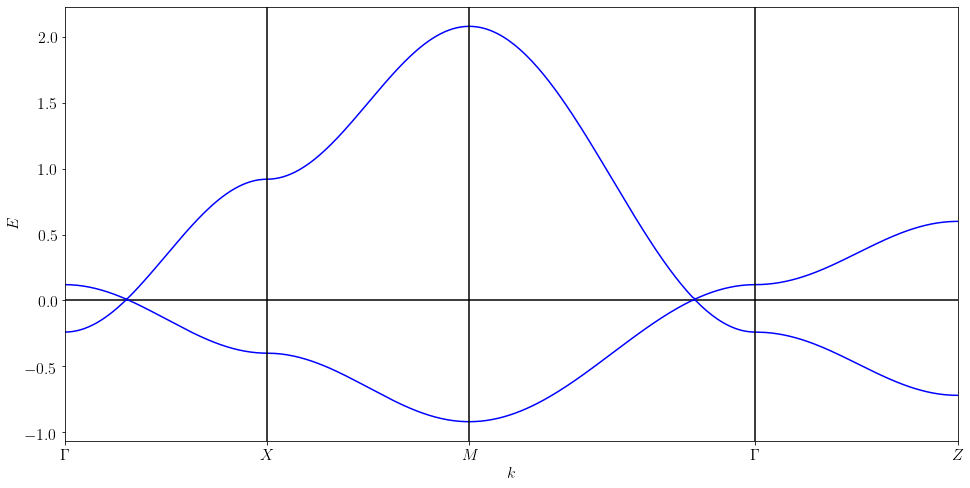

In [125]:
tools.plot_bands_3D(kline0, energies0, k_labels)

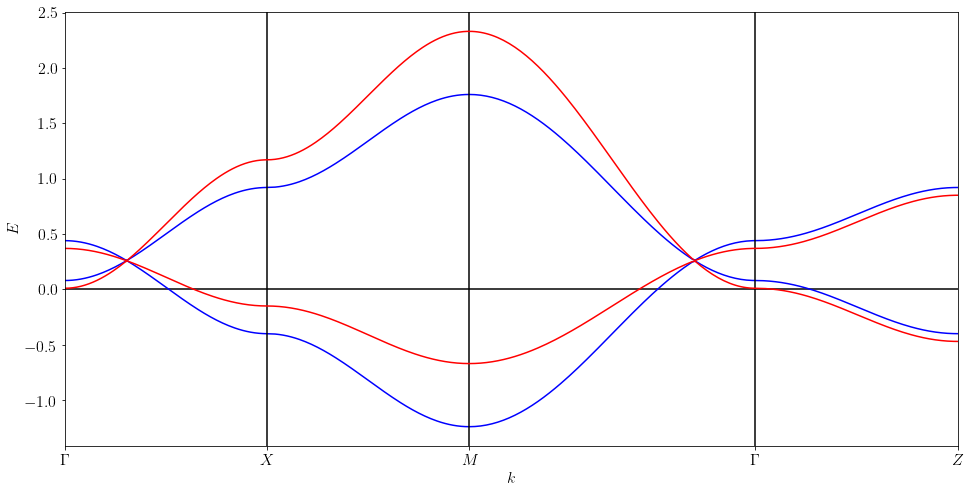

In [129]:
parameters['t0'] = 0.0
kline1, energies1, evecs1 = tools.compute_bands_3D(Ham, parameters, k_points)
tools.plot_bands_3D(kline1, energies1, k_labels)
plt.plot(kline0, energies0[:,0]+0.25, c='r')
plt.plot(kline0, energies0[:,1]+0.25, c='r')

The final model parameters are: $a = 9.69\,\mathrm{Angstrom}$, $t = 0.21\,\mathrm{eV}$, $t_1 = 0.18\,\mathrm{eV}$, $t_2 = 0.17\,\mathrm{eV}$

In units of $t$, the hopping parameters are $t_1 = 0.85$, $t_2 = 0.81$